# 3. Candidate space discussion

The previous notebook turned the day load curve into scheduler-facing user rows. This notebook fills in the missing layer between those user rows and the TDMA scheduler. It uses one worked user case to show how the single-user candidate space is built, how redundant rows are removed, and what is finally stored for later lookup.


## 0. Load the fixed study setting

Notebook 1 fixed the scenario, the radio preset, and the measured PA set. Notebook 2 fixed the user-generation process. Here we reuse those choices and stay with one worked user case so the candidate logic is easy to follow.

The code below loads the study artifacts used in this discussion.


In [1]:
import sys
from pathlib import Path

import matplotlib
matplotlib.use("Agg")
%matplotlib inline
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

for path in (PROJECT_ROOT / "notebooks", PROJECT_ROOT / "src"):
    resolved = str(path.resolve())
    if resolved not in sys.path:
        sys.path.insert(0, resolved)

from configs.day_cycle import DEFAULT_SYNTHETIC_SESSION_GENERATION_CONFIG
from helpers.candidate_space_discussion_helpers import CandidateSpaceHelpers

DOC_IMG_DIR = PROJECT_ROOT / "img"
DOC_IMG_DIR.mkdir(parents=True, exist_ok=True)

# Notebook-wide visual identity: change this once to rerun under the other institutional theme.
helper = CandidateSpaceHelpers(theme="aalto_elec")


In [2]:
artifacts = helper.build_artifacts(
    load_curve_csv=PROJECT_ROOT / "data" / "half_load_curve.csv",
    day_cycle_config=DEFAULT_SYNTHETIC_SESSION_GENERATION_CONFIG,
)


## 1. One user can be served by one PHY configuration

We start with one user at `300 m` and one required rate of `200 Mbps`. This row is only a worked example. The purpose is to make the candidate structure concrete before we look at the full set.

The table below shows one feasible full-frame PHY row for this user. The 3D block then shows the same row on the frame, so the use of slots, PRBs, and layers can be seen directly.


In [3]:
display(helper.render_table(artifacts.single_user_summary))


Distance (m),Required throughput (Mbps),PA,Slots,n_PRB per slot,Allocated PRBs per frame,Layers,MCS index,Achieved throughput (Mbps),Average power (W)
300.0,200.0,4W PA,20,276,5520,2,13,202.864,13.13


Saved figure to C:\Users\henry\Documents\Masters Thesis\code\img\single_user_resource_allocation_candidate.png


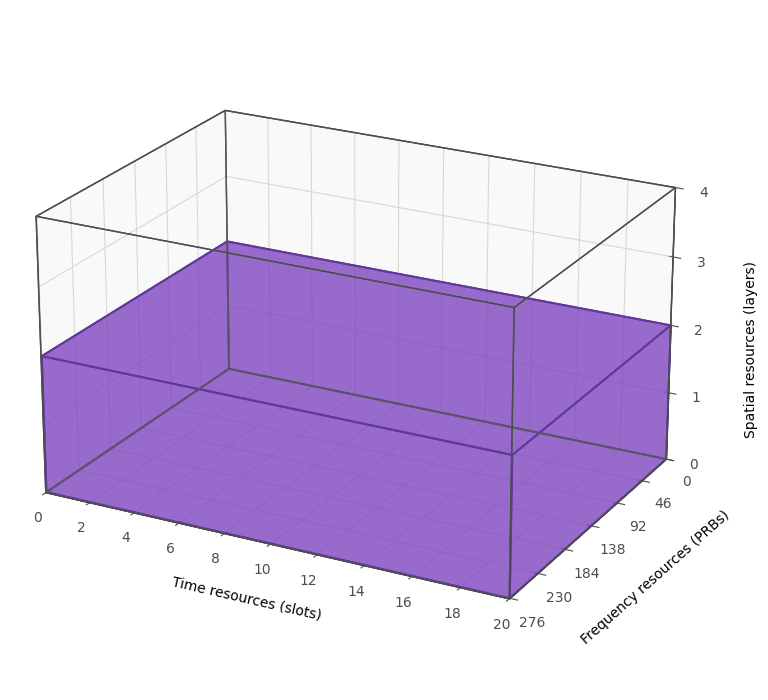

In [4]:
allocation_fig, allocation_ax = helper.plot_candidate_allocation(
    artifacts,
    export_path=DOC_IMG_DIR / "single_user_resource_allocation_candidate.png",
)


One feasible full-frame PHY row for the worked user case at 300 m and 200 Mbps. The block shows how that row occupies time, frequency, and spatial layers within the frame.


## 2. The same throughput can be met in different ways

One feasible row is not yet the candidate space. For the same distance and rate target, several full-frame rows can satisfy the user. They do so with different choices of occupied bandwidth, slot use, layers, and MCS, and those choices lead to different active PA costs.

The comparison table below shows two valid rows near the target rate. The next two plots widen the view to the feasible rows in the `200-205 Mbps` band and show the trade-off between delivered rate, active PA DC power, and total PRB use.


In [5]:
display(helper.render_table(artifacts.slice_comparison))


Role,PA,Slots,n_PRB per slot,Allocated PRBs per frame,Layers,MCS index,Average throughput (Mbps),Active PA DC power (W)
Lower-power row,4W PA,17,241,4097,3,12,200.035,18.861
Lower-resource higher-MCS row,8W PA,13,111,1443,4,21,200.001,73.059


Saved figure to C:\Users\henry\Documents\Masters Thesis\code\img\single_user_same_throughput_tradeoff.png


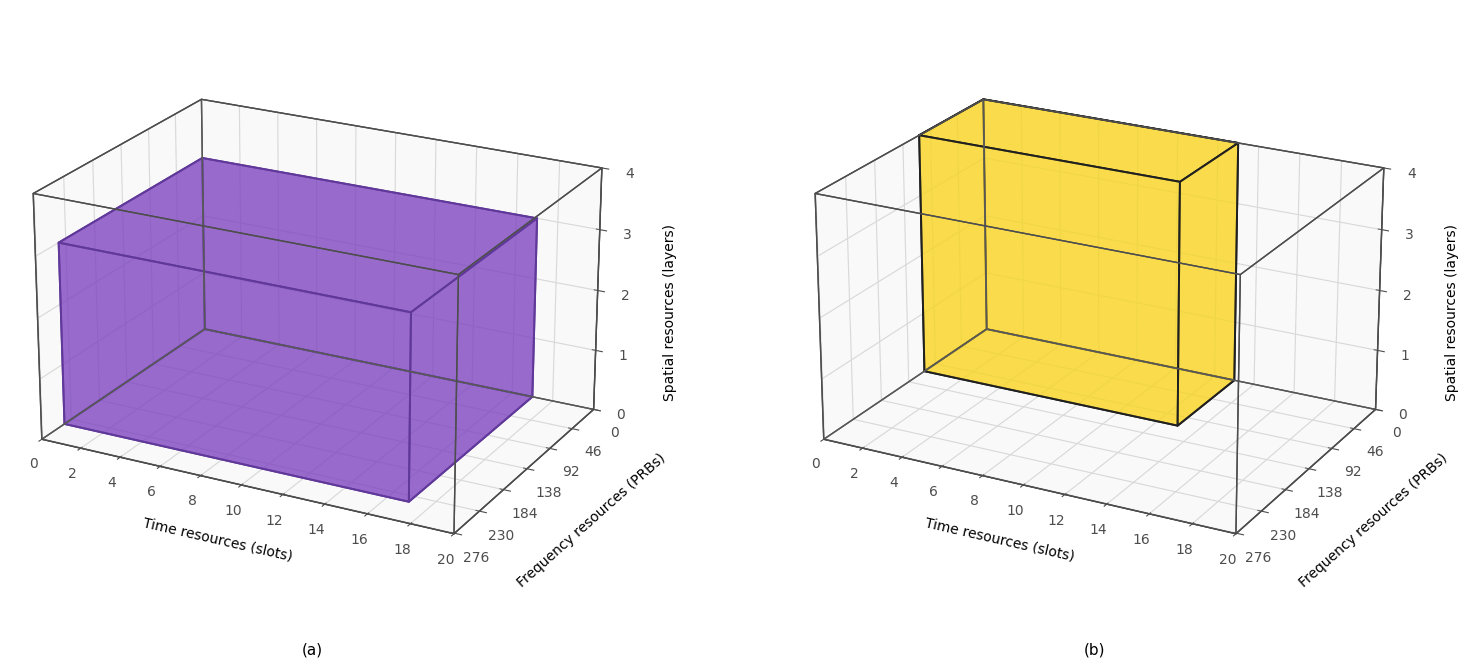

In [6]:
tradeoff_fig, tradeoff_axes = helper.plot_same_throughput_tradeoff(
    artifacts,
    export_path=DOC_IMG_DIR / "single_user_same_throughput_tradeoff.png",
)


Two feasible full-frame PHY rows that both satisfy the worked user demand at 300 m and 200 Mbps: (a) Lower-power operating point. (b) Higher-MCS/ Power comparison with a different resource trade-off.


Saved figure to C:\Users\henry\Documents\Masters Thesis\code\img\single_user_throughput_slice_candidate.png


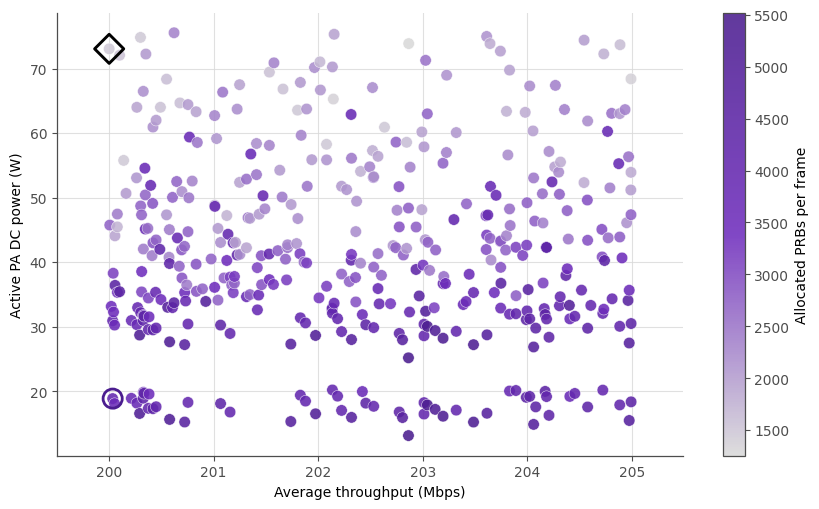

In [7]:
throughput_band_fig, throughput_band_ax = helper.plot_throughput_band(
    artifacts,
    export_path=DOC_IMG_DIR / "single_user_throughput_slice_candidate.png",
)


Feasible full-frame rows in the `200-205 Mbps` band for the worked user case. Marker position shows delivered rate versus active PA DC power, and color shows the total PRBs used over the frame.


## 3. Not every feasible row should be kept

At this stage, the feasible set still contains rows that are never useful later. If one row from the same PA family is no worse in delivered rate, active PA power, and PRB use, then the weaker row does not need to remain.

The figure below applies that same-PA strict dominance rule to the full feasible set and then shows only the rows in the plotted throughput band. This keeps the view comparable with the previous section while making the prune visible.


In [8]:
display(helper.render_table(artifacts.pruning_pair_table))


Role,PA,Slots,n_PRB per slot,Allocated PRBs per frame,Layers,MCS index,Average throughput (Mbps),Active PA DC power (W)
Dominating row,8W PA,18,136,2448,4,14,203.066,38.734
Dominated row,8W PA,16,171,2736,3,16,202.531,39.236


Saved figure to C:\Users\henry\Documents\Masters Thesis\code\img\single_user_pruning_slice_candidate.png


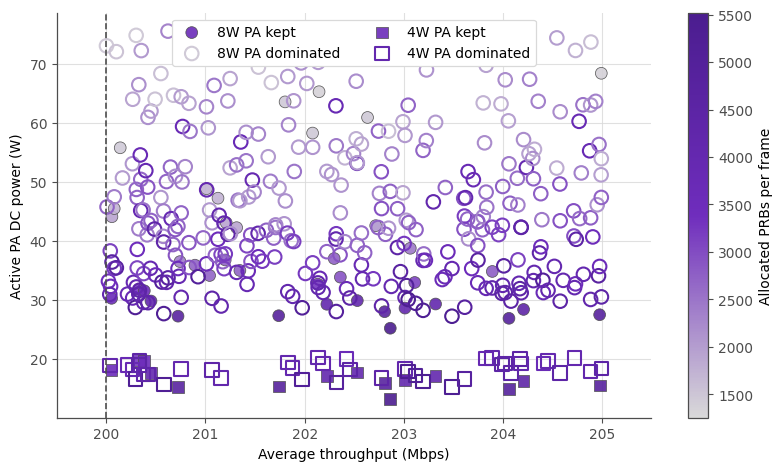

In [9]:
pruning_band_fig, pruning_band_ax = helper.plot_pruning_band(
    artifacts,
    export_path=DOC_IMG_DIR / "single_user_pruning_slice_candidate.png",
)


The same `200-205 Mbps` throughput band after applying the same-PA strict dominance rule. Filled markers are kept rows, hollow markers are removed rows, and color still shows the allocated PRBs per frame.


## 4. Store the pruned frontier for each distance

After pruning, the remaining rows at `300 m` form the stored frontier for that distance bin. This frontier is much smaller than the raw feasible set, but it still preserves the operating points that matter later.

The first plot shows how many full-frame rows remain inside each PA family after pruning. The second plot shows the frontier itself as the stored table used during lookup.


Saved figure to C:\Users\henry\Documents\Masters Thesis\code\img\candidate_table_frontier_compaction.png


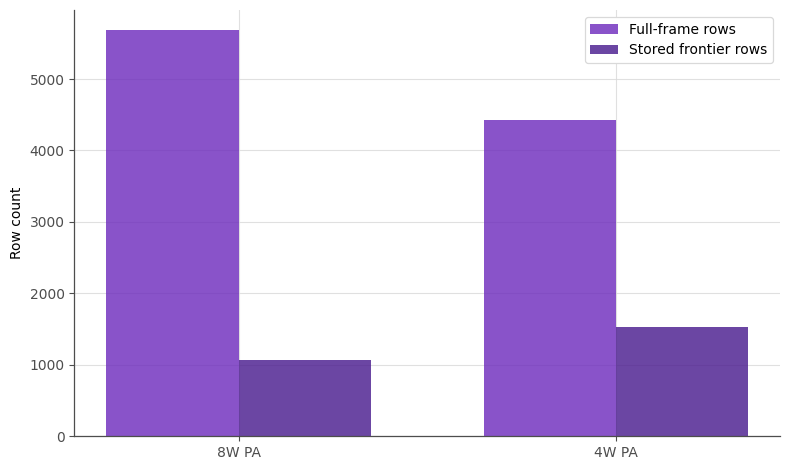

In [10]:
frontier_compaction_fig, frontier_compaction_ax = helper.plot_frontier_compaction(
    artifacts,
    export_path=DOC_IMG_DIR / "candidate_table_frontier_compaction.png",
)


Row-count reduction produced by strict same-PA pruning for the 300 m distance bin. The key shows the full-frame rows before pruning and the stored frontier rows that remain.


Saved figure to C:\Users\henry\Documents\Masters Thesis\code\img\candidate_table_stored_frontier_300m.png


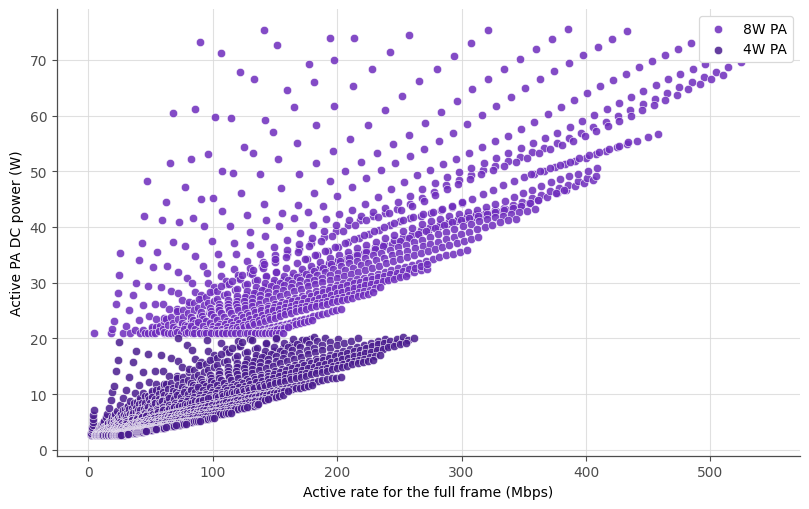

In [11]:
stored_frontier_fig, stored_frontier_ax = helper.plot_pruned_frontier(
    artifacts,
    export_path=DOC_IMG_DIR / "candidate_table_stored_frontier_300m.png",
)


Stored full-frame candidate frontier for the 300 m distance bin. Each point is a full-frame operating row that survives pruning and remains available during later lookup.


## 5. Return to one active bin from the day model

We now reconnect this single-user frontier with the day model built in notebook 2. The first figure marks the worked quarter-hour bin in the day trace, and the second shows the active users inside that bin.

This walkthrough only reads the cached `data/distance_binned_candidate_table.json` table. It does not rebuild the candidate space. The goal here is to show what the lookup stage hands to the scheduler.


Saved figure to C:\Users\henry\Documents\Masters Thesis\code\img\candidate_lookup_bin_context.png


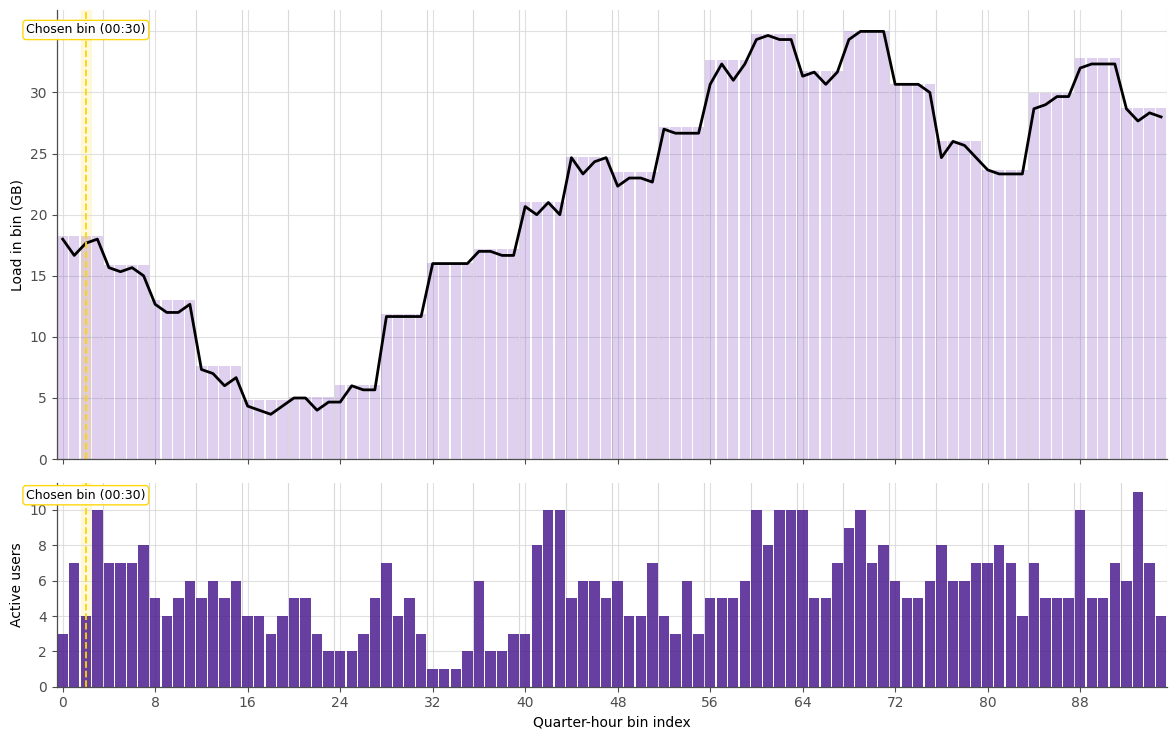

In [12]:
lookup_context_fig, lookup_context_axes = helper.plot_lookup_bin_context(
    artifacts,
    export_path=DOC_IMG_DIR / "candidate_lookup_bin_context.png",
)


Worked quarter-hour bin inside the day-level demand trace. Top: target bin load and the load rebuilt from generated sessions. Bottom: active-user count with the selected lookup bin highlighted.


Saved figure to C:\Users\henry\Documents\Masters Thesis\code\img\candidate_lookup_active_bin_snapshot.png


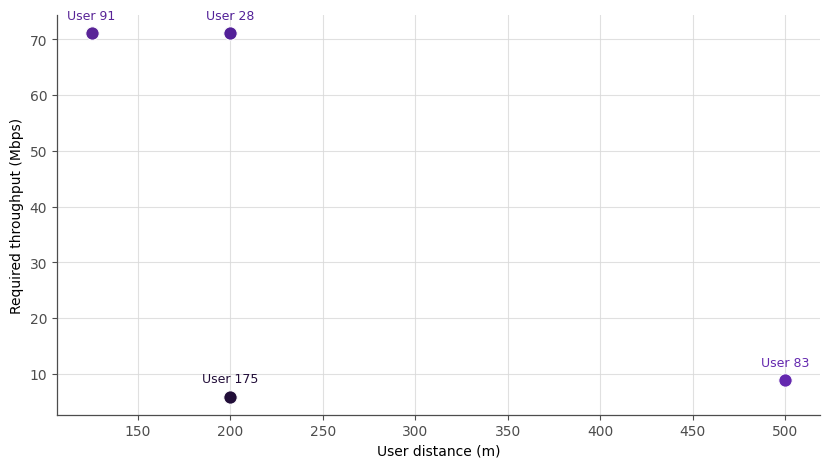

In [13]:
active_bin_fig, active_bin_ax = helper.plot_active_bin_snapshot(
    artifacts,
    export_path=DOC_IMG_DIR / "candidate_lookup_active_bin_snapshot.png",
)


Active users in the selected scheduler bin before candidate lookup. Each point is one user placed by distance and required throughput.


## 6. The bin becomes a set of per-user full-frame menus

Each user is still described only by identity, distance, and required throughput. The lookup step snaps the user to the stored distance bin, retrieves the frontier for that distance, and keeps only the rows that can meet that user's required active rate.

The small multiples below show the result. Faded rows are stored operating points that fail the user's rate target. Brighter rows are the feasible full-frame menus that leave the lookup stage. These menus are the batch table that notebook 4 turns into TDMA rows on the shared frame.


Saved figure to C:\Users\henry\Documents\Masters Thesis\code\img\candidate_lookup_per_user_menus.png


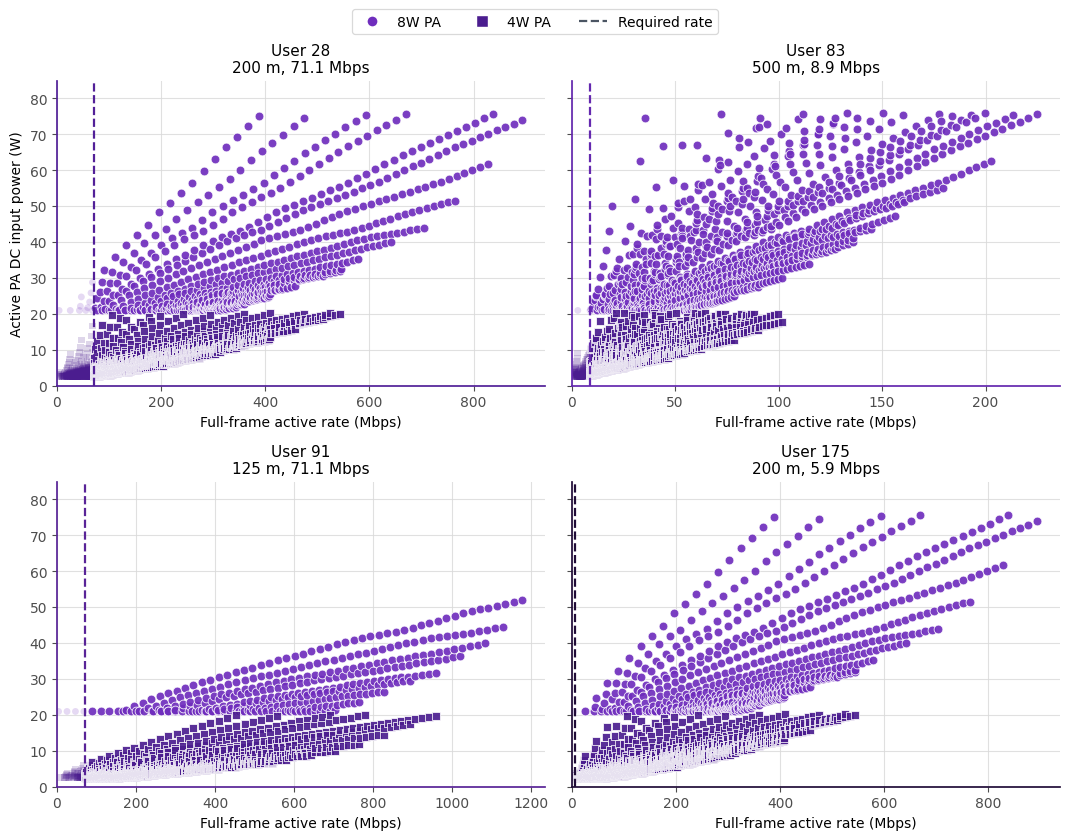

In [14]:
scheduler_input_fig, scheduler_input_axes = helper.plot_scheduler_input_spaces(
    artifacts,
    export_path=DOC_IMG_DIR / "candidate_lookup_per_user_menus.png",
)


Per-user full-frame candidate menus after lookup. Faded rows are stored operating points that fail the user's required active rate, and brighter rows are the feasible menus passed into the TDMA scheduler.


This notebook stops where the single-user work is complete for one active bin. Each user now carries a compact full-frame feasible set read from the stored frontier. The next notebook takes these per-user menus and solves the joint TDMA allocation on one shared slot window.
